In [ ]:
import numpy as np
import math
import random
import os
import torch
from glob import glob
import scipy.spatial.distance
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
import plotly.graph_objects as go
!pip install path.py;
!pip install trimesh
from path import Path
import trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 736.6/736.6 kB 15.0 MB/s eta 0:00:00


In [ ]:
!wget http://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip
!unzip -q ModelNet10.zip;

--2025-11-25 20:57:43--  http://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip
Resolving 3dvision.princeton.edu (3dvision.princeton.edu)... 128.112.136.67
Connecting to 3dvision.princeton.edu (3dvision.princeton.edu)|128.112.136.67|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip [following]
--2025-11-25 20:57:44--  https://3dvision.princeton.edu/projects/2014/3DShapeNets/ModelNet10.zip
Connecting to 3dvision.princeton.edu (3dvision.princeton.edu)|128.112.136.67|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 473402300 (451M) [application/zip]
Saving to: ‘ModelNet10.zip’

ModelNet10.zip      100%[===================>] 451.47M  27.3MB/s    in 16s     

2025-11-25 20:58:00 (27.5 MB/s) - ‘ModelNet10.zip’ saved [473402300/473402300]



In [ ]:
if torch.cuda.is_available():
  if_cuda=True
else:
  if_cuda=False
seed_value=0
np.random.seed(seed_value) # cpu vars
torch.manual_seed(seed_value) # cpu  vars
random.seed(seed_value) # Python
os.environ['PYTHONHASHSEED']=str(seed_value)
if if_cuda:
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value) # gpu vars
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
path = Path("ModelNet10")
folders = [dir for dir in sorted(os.listdir(path)) if os.path.isdir(path/dir)]
classes = {folder: i for i, folder in enumerate(folders)};
classes
pcd = trimesh.load("ModelNet10/sofa/train/sofa_0002.off")
print(pcd)
print(pcd.vertices.shape, pcd.faces.shape)
scene = trimesh.scene.Scene()
scene.add_geometry(pcd)
scene.show()
verts = pcd.vertices
faces = pcd.faces
print("Vertices:\n", verts[:5]) # set of points in 3D space
print("Faces:\n", faces[:5])  # set of vertex indices triplets
v = trimesh.points.PointCloud(verts, colors=np.tile(np.array([0, 0, 0, 1]), (len(verts), 1)))
scene = trimesh.scene.Scene()
scene.add_geometry(v)
scene.show()
class PointSampler_Trimesh(object):
    def __init__(self, output_size):
        assert isinstance(output_size, int)
        self.output_size = output_size
    def __call__(self, mesh):
        sampled_pc = trimesh.sample.sample_surface(mesh,self.output_size) #does some extra reduction step if two points are really close
        pc = sampled_pc[0]
        return pc
pointcloud = PointSampler_Trimesh(40000)(pcd)
p = trimesh.points.PointCloud(pointcloud, colors=np.tile(np.array([0, 0, 0, 1]), (len(pointcloud), 1)))
scene = trimesh.scene.Scene()
scene.add_geometry(p)
scene.show()


<trimesh.Trimesh(vertices.shape=(5630, 3), faces.shape=(11354, 3))>
(5630, 3) (11354, 3)
Vertices:
 [[32.98545 -8.56285 39.55135]
 [29.8576  13.25175 10.96485]
 [32.0856  10.60875 29.60695]
 [29.0094  -5.34145 20.65725]
 [17.2913  23.47475  8.49945]]
Faces:
 [[0 1 2]
 [0 3 1]
 [2 4 5]
 [4 2 1]
 [0 2 6]]


In [ ]:
def random_point_sample(points, npoint):
  indexes = random.sample(range(points.shape[0]), npoint)
  return points[indexes]
randomp = random_point_sample(p.vertices, 2048)
sp = trimesh.points.PointCloud(randomp, colors=np.tile(np.array([0, 0, 0, 1]), (len(randomp), 1)))
scene = trimesh.scene.Scene()
scene.add_geometry(sp)
scene.show()

In [ ]:
def farthest_point_sample(points, npoint):
    """
    Input:
        point: xyz points
        npoint: number of samples
    Return:
        centroids: sampled pointcloud [npoint, D]
    """
    N, D = points.shape
    xyz = points[:,:3]
    centroids = np.zeros((npoint,))
    distance = np.ones((N,)) * 1e10
    farthest = np.random.randint(0, N)  # start with a random point
    for i in range(npoint):
        centroids[i] = farthest
        centroid = xyz[farthest, :]
        dist = np.sum((xyz - centroid) ** 2, -1)  # calculate distance of centroid with all the points
        mask = dist < distance                    # mask out already sampled points
        distance[mask] = dist[mask]
        farthest = np.argmax(distance, -1)        # get farthest point index
    points = points[centroids.astype(np.int32)]
    return points

sampledp = farthest_point_sample(p.vertices, 2048)
sp = trimesh.points.PointCloud(sampledp, colors=np.tile(np.array([0, 0, 0, 1]), (len(sampledp), 1)))
scene = trimesh.scene.Scene()
scene.add_geometry(sp)
scene.show()

In [ ]:
# Normalizing: Bring the mean of the point cloud to the origin (0,0,0) and scale the point cloud size to fit in a unit sphere
class Normalize(object):
    def __call__(self, pointcloud):
        assert len(pointcloud.shape)==2

        norm_pointcloud = pointcloud - np.mean(pointcloud, axis=0)
        norm_pointcloud /= np.max(np.linalg.norm(norm_pointcloud, axis=1))

        return  norm_pointcloud
norm_pointcloud = Normalize()(sampledp)


In [ ]:
# Data augmentation
class RandRotation_z(object):
    def __call__(self, pointcloud):
        assert len(pointcloud.shape)==2

        theta = random.random() * 2. * math.pi
        rot_matrix = np.array([[ math.cos(theta), -math.sin(theta),    0],
                               [ math.sin(theta),  math.cos(theta),    0],
                               [0,                             0,      1]])

        rot_pointcloud = rot_matrix.dot(pointcloud.T).T
        return  rot_pointcloud

class RandomNoise(object):
    def __call__(self, pointcloud):
        assert len(pointcloud.shape)==2

        noise = np.random.normal(0, 0.02, (pointcloud.shape))

        noisy_pointcloud = pointcloud + noise
        return  noisy_pointcloud
rot_pointcloud = RandRotation_z()(norm_pointcloud)
noisy_rot_pointcloud = RandomNoise()(rot_pointcloud)
p = trimesh.points.PointCloud(noisy_rot_pointcloud, colors=np.tile(np.array([0, 0, 0, 1]), (len(noisy_rot_pointcloud), 1)))

scene = trimesh.scene.Scene()
scene.add_geometry(p)
scene.show()

In [ ]:
class ToTensor(object):
    def __call__(self, pointcloud):
        assert len(pointcloud.shape)==2

        return torch.from_numpy(pointcloud)
def default_transforms():
    return transforms.Compose([
                                PointSampler_Trimesh(1024),
                                Normalize(),
                                ToTensor()
                              ])

In [ ]:
class PointCloudData(Dataset):
    def __init__(self, root_dir, valid=False, folder="train", transform=default_transforms()):
        self.root_dir = root_dir
        folders = [dir for dir in sorted(os.listdir(root_dir)) if os.path.isdir(root_dir/dir)]
        self.classes = {folder: i for i, folder in enumerate(folders)}
        self.transforms = transform if not valid else default_transforms()
        self.valid = valid
        self.files = []
        for category in self.classes.keys():
            new_dir = root_dir/Path(category)/folder
            for file in os.listdir(new_dir):
                if file.endswith('.off'):
                    sample = {}
                    sample['pcd_path'] = new_dir/file
                    sample['category'] = category
                    self.files.append(sample)

    def __len__(self):
        return len(self.files)

    def __preproc__(self, file):
        pcd = trimesh.load(file)
        verts = pcd.vertices
        faces = pcd.faces

        if self.transforms:
            pointcloud = self.transforms((pcd))
        return pointcloud

    def __getitem__(self, idx):
        pcd_path = self.files[idx]['pcd_path']
        category = self.files[idx]['category']

        pointcloud = self.__preproc__(pcd_path)

        return {'pointcloud': pointcloud,
                'category': self.classes[category]}

train_transforms = transforms.Compose([
                    PointSampler_Trimesh(1024),
                    Normalize(),
                    RandRotation_z(),
                    RandomNoise(),
                    ToTensor()
                    ])
train_ds = PointCloudData(path, transform=train_transforms)
valid_ds = PointCloudData(path, valid=True, folder='test')
inv_classes = {i: cat for cat, i in train_ds.classes.items()};
inv_classes

{0: 'bathtub',
 1: 'bed',
 2: 'chair',
 3: 'desk',
 4: 'dresser',
 5: 'monitor',
 6: 'night_stand',
 7: 'sofa',
 8: 'table',
 9: 'toilet'}

In [ ]:
print('Train dataset size: ', len(train_ds))
print('Valid dataset size: ', len(valid_ds))
print('Number of classes: ', len(train_ds.classes))
print('Sample pointcloud shape: ', train_ds[0]['pointcloud'].size())
print('Class: ', inv_classes[train_ds[0]['category']])


Train dataset size:  3991
Valid dataset size:  908
Number of classes:  10
Sample pointcloud shape:  torch.Size([1024, 3])
Class:  bathtub


In [ ]:
train_loader = DataLoader(dataset=train_ds, batch_size=32, shuffle=True,drop_last=True)
valid_loader = DataLoader(dataset=valid_ds, batch_size=64,drop_last=True)

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F

class Tnet(nn.Module):
   def __init__(self, k=3):
      super().__init__()
      self.k=k
      self.conv1 = nn.Conv1d(k,64,1)
      self.conv2 = nn.Conv1d(64,128,1)
      self.conv3 = nn.Conv1d(128,1024,1)
      self.fc1 = nn.Linear(1024,512)
      self.fc2 = nn.Linear(512,256)
      self.fc3 = nn.Linear(256,k*k)

      self.bn1 = nn.BatchNorm1d(64)
      self.bn2 = nn.BatchNorm1d(128)
      self.bn3 = nn.BatchNorm1d(1024)
      self.bn4 = nn.BatchNorm1d(512)
      self.bn5 = nn.BatchNorm1d(256)


   def forward(self, input):
      # input.shape == (bs,n,3)
      bs = input.size(0)
      xb = F.relu(self.bn1(self.conv1(input)))
      xb = F.relu(self.bn2(self.conv2(xb)))
      xb = F.relu(self.bn3(self.conv3(xb)))
      pool = nn.MaxPool1d(xb.size(-1))(xb)
      flat = nn.Flatten(1)(pool)
      xb = F.relu(self.bn4(self.fc1(flat)))
      xb = F.relu(self.bn5(self.fc2(xb)))

      #initialize as identity
      init = torch.eye(self.k, requires_grad=True).repeat(bs,1,1)
      if xb.is_cuda:
        init=init.cuda()
      matrix = self.fc3(xb).view(-1,self.k,self.k) + init
      return matrix


class Transform(nn.Module):
   def __init__(self):
        super().__init__()
        self.input_transform = Tnet(k=3)
        self.feature_transform = Tnet(k=64)
        self.conv1 = nn.Conv1d(3,64,1)

        self.conv2 = nn.Conv1d(64,128,1)
        self.conv3 = nn.Conv1d(128,1024,1)


        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)

   def forward(self, input):
        matrix3x3 = self.input_transform(input)
        # batch matrix multiplication
        xb = torch.bmm(torch.transpose(input,1,2), matrix3x3).transpose(1,2)

        xb = F.relu(self.bn1(self.conv1(xb)))

        matrix64x64 = self.feature_transform(xb)
        xb = torch.bmm(torch.transpose(xb,1,2), matrix64x64).transpose(1,2)

        xb = F.relu(self.bn2(self.conv2(xb)))
        xb = self.bn3(self.conv3(xb))
        xb = nn.MaxPool1d(xb.size(-1))(xb)
        output = nn.Flatten(1)(xb)
        return output, matrix3x3, matrix64x64

class PointNet(nn.Module):
    def __init__(self, classes = 10):
        super().__init__()
        self.transform = Transform()
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, classes)


        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(p=0.3)
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, input):
        xb, matrix3x3, matrix64x64 = self.transform(input)
        xb = F.relu(self.bn1(self.fc1(xb)))
        xb = F.relu(self.bn2(self.dropout(self.fc2(xb))))
        output = self.fc3(xb)
        return self.logsoftmax(output), matrix3x3, matrix64x64


In [ ]:

def pointnetloss(outputs, labels, m3x3, m64x64, alpha = 0.0001):
    criterion = torch.nn.NLLLoss()  # Classification loss

    bs=outputs.size(0)
    id3x3 = torch.eye(3, requires_grad=True).repeat(bs,1,1)
    id64x64 = torch.eye(64, requires_grad=True).repeat(bs,1,1)
    if outputs.is_cuda:
        id3x3=id3x3.cuda()
        id64x64=id64x64.cuda()
    diff3x3 = id3x3-torch.bmm(m3x3,m3x3.transpose(1,2))
    diff64x64 = id64x64-torch.bmm(m64x64,m64x64.transpose(1,2))
    return criterion(outputs, labels) + alpha * (torch.norm(diff3x3)+torch.norm(diff64x64)) / float(bs)


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
pointnet = PointNet()
pointnet.to(device);
optimizer = torch.optim.Adam(pointnet.parameters(), lr=0.001)

cuda:0


In [ ]:
def train(model, train_loader, val_loader=None, epochs=15, save=True):
    # Lists to store metrics for plotting
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    iterations = []
    iteration_count = 0

    for epoch in range(epochs):
        pointnet.train()
        running_loss = 0.0
        epoch_correct = 0
        epoch_total = 0

        for i, data in enumerate(train_loader, 0):
            inputs, labels = data['pointcloud'].to(device).float(), data['category'].to(device)
            optimizer.zero_grad()
            outputs, m3x3, m64x64 = pointnet(inputs.transpose(1,2))

            loss = pointnetloss(outputs, labels, m3x3, m64x64)
            loss.backward()
            optimizer.step()

            # Calculate training accuracy for this batch
            _, predicted = torch.max(outputs.data, 1)
            epoch_total += labels.size(0)
            epoch_correct += (predicted == labels).sum().item()

            # print statistics
            running_loss += loss.item()
            if i % 10 == 9:    # print every 10 mini-batches
                avg_loss = running_loss / 10
                train_acc = 100. * epoch_correct / epoch_total

                # Store metrics
                iterations.append(iteration_count)
                train_losses.append(avg_loss)
                train_accs.append(train_acc)

                print('[Epoch: %d, Batch: %4d / %4d], loss: %.3f, train_acc: %.2f %%' %
                    (epoch + 1, i + 1, len(train_loader), avg_loss, train_acc))
                running_loss = 0.0

            iteration_count += 1

        pointnet.eval()
        correct = total = 0
        val_running_loss = 0.0

        # validation
        if val_loader:
            with torch.no_grad():
                for data in val_loader:
                    inputs, labels = data['pointcloud'].to(device).float(), data['category'].to(device)
                    outputs, m3x3, m64x64 = pointnet(inputs.transpose(1,2))

                    # Calculate validation loss
                    loss = pointnetloss(outputs, labels, m3x3, m64x64)
                    val_running_loss += loss.item()

                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            val_acc = 100. * correct / total
            avg_val_loss = val_running_loss / len(val_loader)

            # Store validation metrics
            val_losses.append(avg_val_loss)
            val_accs.append(val_acc)

            print('Valid accuracy: %.2f %%, Valid loss: %.3f' % (val_acc, avg_val_loss))

        # save the model
        if save:
            torch.save(pointnet.state_dict(), "save_"+str(epoch)+".pth")

    # Plot all metrics
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Training Loss vs Iterations
    axes[0, 0].plot(iterations, train_losses, 'b-', label='Training Loss')
    axes[0, 0].set_xlabel('Iterations')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training Loss vs Iterations')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Training Accuracy vs Iterations
    axes[0, 1].plot(iterations, train_accs, 'g-', label='Training Accuracy')
    axes[0, 1].set_xlabel('Iterations')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Training Accuracy vs Iterations')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Validation Loss vs Epochs
    if val_loader:
        epochs_list = list(range(1, len(val_losses) + 1))
        axes[1, 0].plot(epochs_list, val_losses, 'r-', label='Validation Loss')
        axes[1, 0].set_xlabel('Epochs')
        axes[1, 0].set_ylabel('Loss')
        axes[1, 0].set_title('Validation Loss vs Epochs')
        axes[1, 0].legend()
        axes[1, 0].grid(True)

        # Validation Accuracy vs Epochs
        axes[1, 1].plot(epochs_list, val_accs, 'm-', label='Validation Accuracy')
        axes[1, 1].set_xlabel('Epochs')
        axes[1, 1].set_ylabel('Accuracy (%)')
        axes[1, 1].set_title('Validation Accuracy vs Epochs')
        axes[1, 1].legend()
        axes[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig('training_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nTraining completed!")
    print(f"Final Training Accuracy: {train_accs[-1]:.2f}%")
    if val_loader:
        print(f"Final Validation Accuracy: {val_accs[-1]:.2f}%")
        print(f"Final Validation Loss: {val_losses[-1]:.3f}")

[Epoch: 1, Batch:   10 /  124], loss: 2.166, train_acc: 27.81 %
[Epoch: 1, Batch:   20 /  124], loss: 1.669, train_acc: 35.78 %
[Epoch: 1, Batch:   30 /  124], loss: 1.388, train_acc: 42.60 %
[Epoch: 1, Batch:   40 /  124], loss: 1.343, train_acc: 45.55 %
[Epoch: 1, Batch:   50 /  124], loss: 1.253, train_acc: 48.00 %
[Epoch: 1, Batch:   60 /  124], loss: 1.059, train_acc: 50.31 %
[Epoch: 1, Batch:   70 /  124], loss: 0.951, train_acc: 53.12 %
[Epoch: 1, Batch:   80 /  124], loss: 1.102, train_acc: 54.80 %
[Epoch: 1, Batch:   90 /  124], loss: 1.069, train_acc: 55.69 %
[Epoch: 1, Batch:  100 /  124], loss: 0.921, train_acc: 56.97 %
[Epoch: 1, Batch:  110 /  124], loss: 0.852, train_acc: 58.18 %
[Epoch: 1, Batch:  120 /  124], loss: 0.807, train_acc: 59.38 %
Valid accuracy: 46.32 %, Valid loss: 1.623
[Epoch: 2, Batch:   10 /  124], loss: 0.870, train_acc: 68.44 %
[Epoch: 2, Batch:   20 /  124], loss: 0.907, train_acc: 68.91 %
[Epoch: 2, Batch:   30 /  124], loss: 0.734, train_acc: 70.73

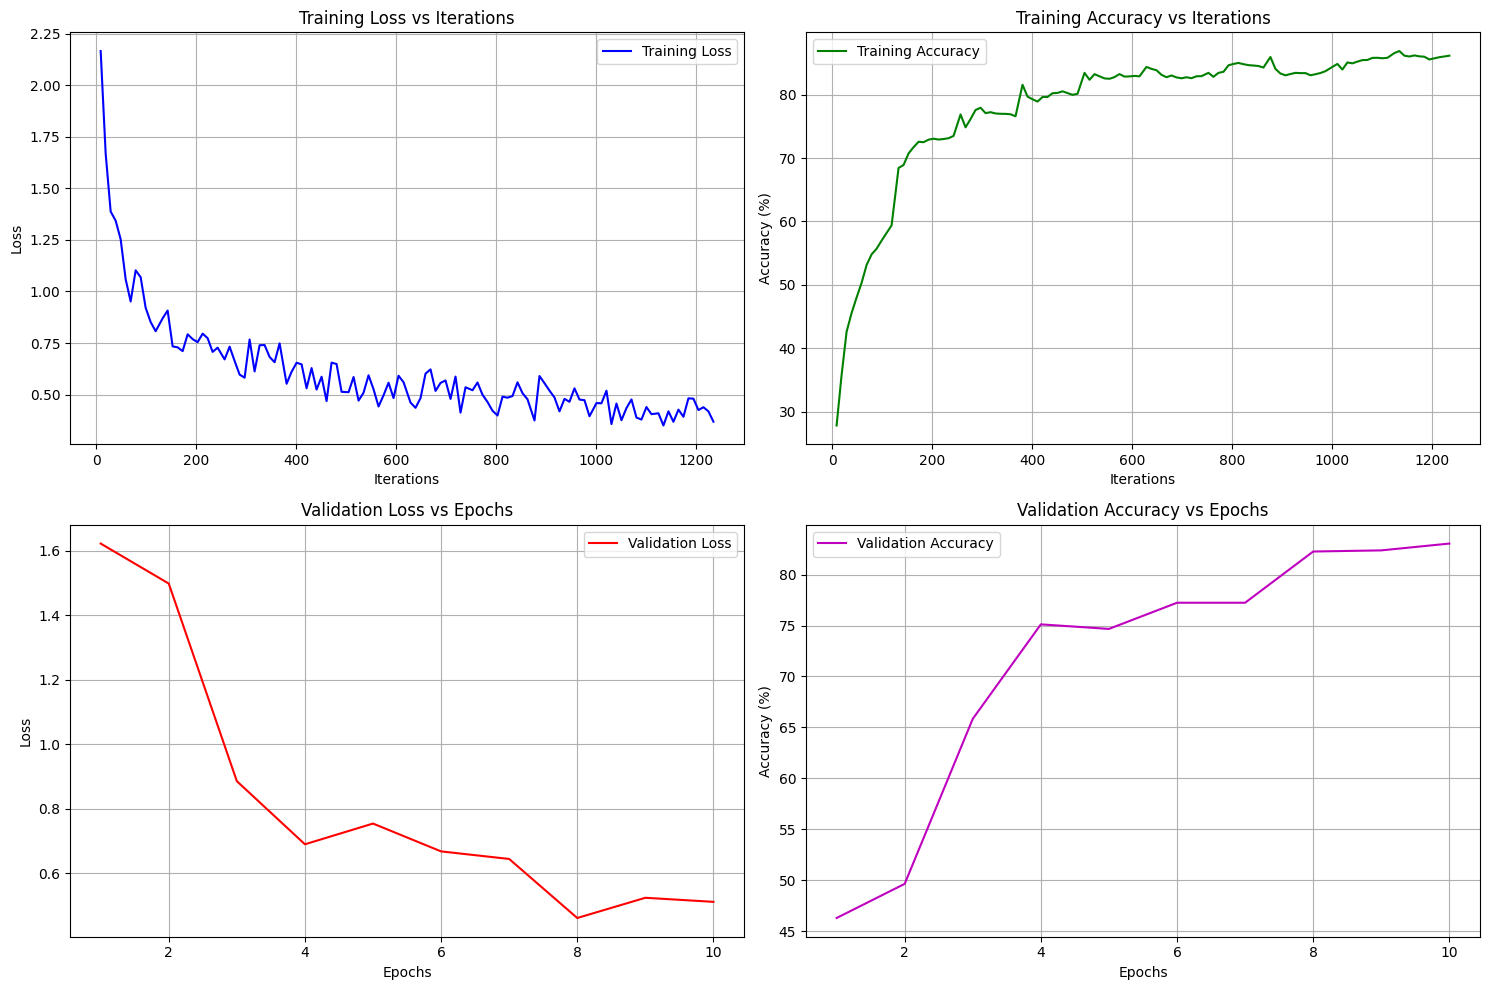


Training completed!
Final Training Accuracy: 86.15%
Final Validation Accuracy: 83.04%
Final Validation Loss: 0.512


In [ ]:
train(pointnet, train_loader, valid_loader, 1, save=True)

In [ ]:
from sklearn.metrics import confusion_matrix
!gdown --id 182FvuCfh1z_H3kBInXiX2wgy-ypRULkK
pointnet = PointNet()
pointnet.load_state_dict(torch.load('pointnet_cls.pth',map_location=torch.device('cpu')))
pointnet.eval();

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=182FvuCfh1z_H3kBInXiX2wgy-ypRULkK
To: /content/pointnet_cls.pth
100% 13.9M/13.9M [00:00<00:00, 122MB/s] 


Batch [   1 /   14], loss: 0.744, batch_acc: 82.81 %, cumulative_acc: 82.81 %
Batch [   2 /   14], loss: 0.104, batch_acc: 95.31 %, cumulative_acc: 89.06 %
Batch [   3 /   14], loss: 0.027, batch_acc: 100.00 %, cumulative_acc: 92.71 %
Batch [   4 /   14], loss: 0.171, batch_acc: 95.31 %, cumulative_acc: 93.36 %
Batch [   5 /   14], loss: 1.721, batch_acc: 37.50 %, cumulative_acc: 82.19 %
Batch [   6 /   14], loss: 1.228, batch_acc: 45.31 %, cumulative_acc: 76.04 %
Batch [   7 /   14], loss: 0.724, batch_acc: 59.38 %, cumulative_acc: 73.66 %
Batch [   8 /   14], loss: 0.886, batch_acc: 68.75 %, cumulative_acc: 73.05 %
Batch [   9 /   14], loss: 0.406, batch_acc: 85.94 %, cumulative_acc: 74.48 %
Batch [  10 /   14], loss: 0.217, batch_acc: 95.31 %, cumulative_acc: 76.56 %
Batch [  11 /   14], loss: 0.322, batch_acc: 96.88 %, cumulative_acc: 78.41 %
Batch [  12 /   14], loss: 0.324, batch_acc: 92.19 %, cumulative_acc: 79.56 %
Batch [  13 /   14], loss: 0.328, batch_acc: 89.06 %, cumulativ

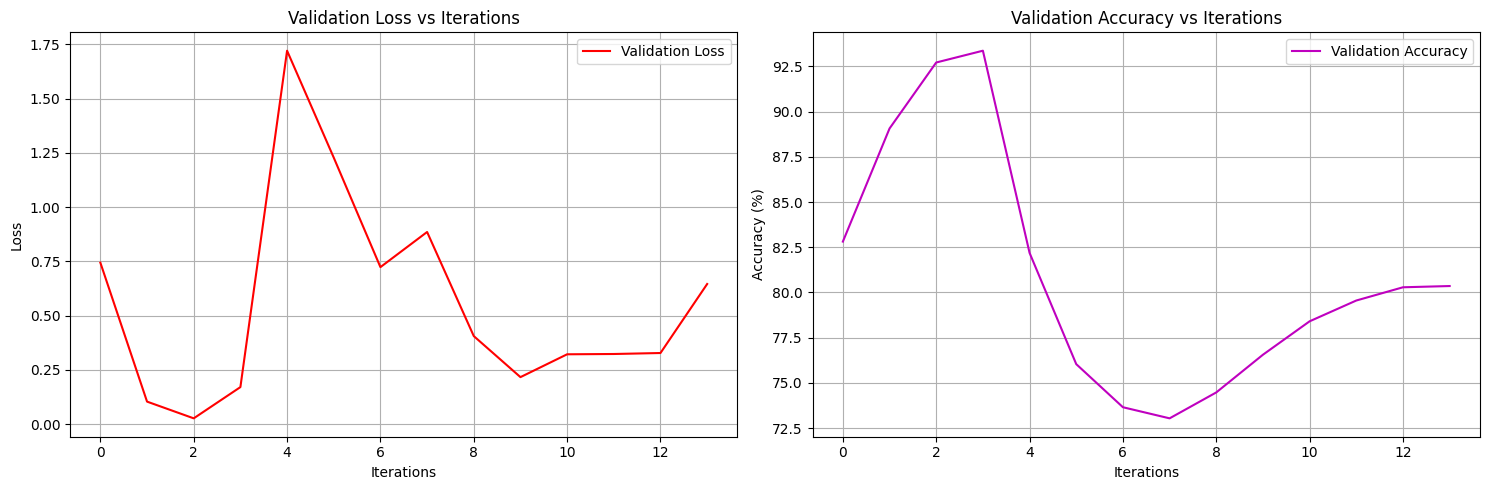


Validation completed!
Final Validation Accuracy: 80.36%
Average Validation Loss: 0.561


In [ ]:
all_preds = []
all_labels = []
val_losses = []
val_accs = []
iterations = []
correct = 0
total = 0

with torch.no_grad():
    for i, data in enumerate(valid_loader):
        inputs, labels = data['pointcloud'].float(), data['category']
        outputs, m3x3, m64x64 = pointnet(inputs.transpose(1,2))

        # Calculate validation loss
        loss = pointnetloss(outputs, labels, m3x3, m64x64)

        _, preds = torch.max(outputs.data, 1)

        # Calculate accuracy for this batch
        batch_correct = (preds == labels).sum().item()
        batch_total = labels.size(0)
        correct += batch_correct
        total += batch_total

        batch_acc = 100. * batch_correct / batch_total
        current_acc = 100. * correct / total

        # Store metrics
        val_losses.append(loss.item())
        val_accs.append(current_acc)
        iterations.append(i)

        all_preds += list(preds.numpy())
        all_labels += list(labels.numpy())

        print('Batch [%4d / %4d], loss: %.3f, batch_acc: %.2f %%, cumulative_acc: %.2f %%' %
              (i+1, len(valid_loader), loss.item(), batch_acc, current_acc))

# Plot validation metrics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Validation Loss vs Iterations
axes[0].plot(iterations, val_losses, 'r-', label='Validation Loss')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Loss')
axes[0].set_title('Validation Loss vs Iterations')
axes[0].legend()
axes[0].grid(True)

# Validation Accuracy vs Iterations
axes[1].plot(iterations, val_accs, 'm-', label='Validation Accuracy')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Validation Accuracy vs Iterations')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('validation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nValidation completed!")
print(f"Final Validation Accuracy: {val_accs[-1]:.2f}%")
print(f"Average Validation Loss: {sum(val_losses)/len(val_losses):.3f}")

In [ ]:
cm = confusion_matrix(all_labels, all_preds);
cm

array([[ 40,  10,   0,   0,   0,   0,   0,   0,   0,   0],
       [  1,  96,   2,   0,   0,   0,   0,   1,   0,   0],
       [  0,   0, 100,   0,   0,   0,   0,   0,   0,   0],
       [  1,   3,   1,  32,   6,   0,  17,   5,  20,   1],
       [  0,   0,   0,   0,  41,   0,  44,   0,   1,   0],
       [  0,   0,   1,   0,  24,  72,   2,   1,   0,   0],
       [  0,   0,   1,   0,   6,   0,  78,   0,   1,   0],
       [  0,   1,   1,   0,   1,   0,   1,  96,   0,   0],
       [  0,   0,   0,   5,   0,   0,   1,   0,  94,   0],
       [  1,   0,  13,   0,   0,   0,   2,   1,   0,  71]])

In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

# function from https://deeplizard.com/learn/video/0LhiS6yu2qQ
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Normalized confusion matrix


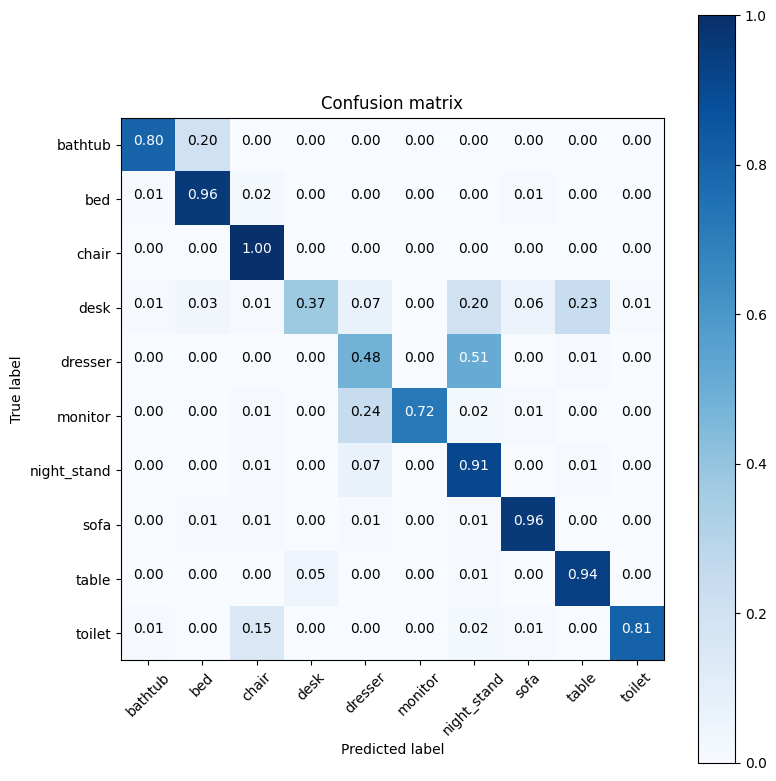

In [ ]:
plt.figure(figsize=(8,8))
plot_confusion_matrix(cm, list(classes.keys()), normalize=True)

Confusion matrix, without normalization


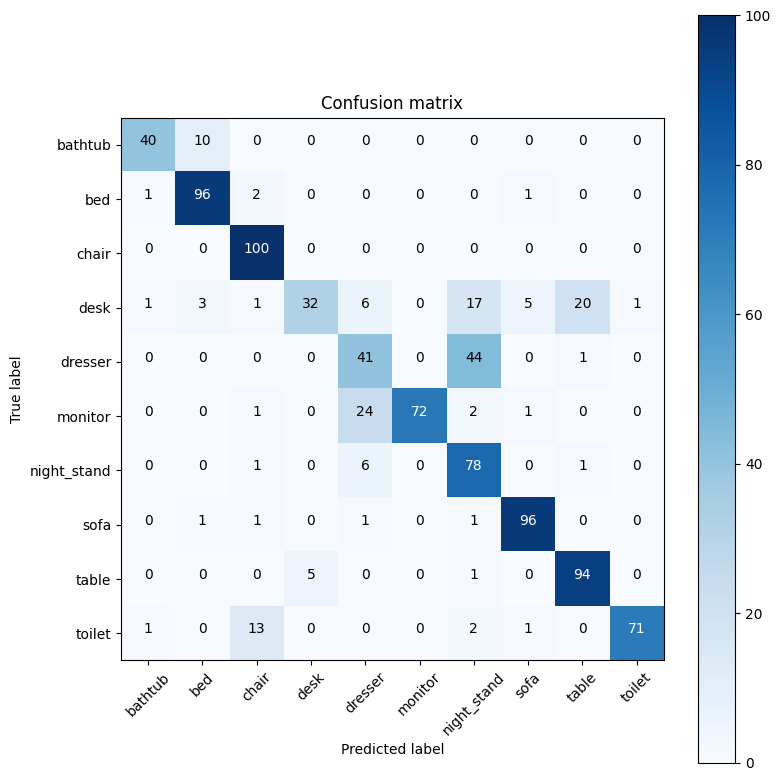

In [ ]:
plt.figure(figsize=(8,8))
plot_confusion_matrix(cm, list(classes.keys()), normalize=False)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


Accuracy:  0.8036
Precision: 0.8301
Recall:    0.8036
F1 Score:  0.7975
